# Exp G: EfficientNet-B3 + CBAM + ASL + Strong Augmentation

**Cai tien so voi Exp C (EffNet-B0+CBAM+ASL, Test mAP=0.6537):**
1. **EfficientNet-B3** (12M params) thay B0 (3.63M) - tang capacity 3.3x cho 80 lop COCO.
2. **Dropout 0.5** (tang tu 0.3) - regularize manh hon de CBAM khong overfit tren 16k anh.
3. **Strong Augmentation** (RandAugment N=2,M=9 + RandomErasing p=0.25).
4. **img_size=300** - resolution toi uu cho EfficientNet-B3.


In [1]:
## 1. CÀI ĐẶT MÔI TRƯỜNG VÀ KẾT NỐI MÃ NGUỒN
!pip install timm pycocotools torchmetrics scikit-learn pyyaml matplotlib seaborn -q
import os
from pathlib import Path
import matplotlib.pyplot as plt
import json
import torch

REPO_URL = 'https://github.com/Thinh59/ECAAL.git'
REPO_DIR = Path('/kaggle/working/ECAAL')

if REPO_DIR.exists():
    os.system(f'git -C {REPO_DIR} pull')
else:
    os.system(f'git clone {REPO_URL} {REPO_DIR}')

import sys
sys.path.insert(0, str(REPO_DIR / 'src'))

Cloning into '/kaggle/working/ECAAL'...


In [2]:
## 2. CHUẨN BỊ DỮ LIỆU ĐỒNG NHẤT
import shutil
SRC_SUBSET = Path('/kaggle/input/datasets/thinhha59/models/results/data/coco_subset')
SUBSET_DIR = Path('/kaggle/working/data/coco_subset')
SUBSET_DIR.mkdir(parents=True, exist_ok=True)
if SRC_SUBSET.exists():
    for fname in ['subset_train_ids.json', 'subset_val_ids.json', 'subset_test_ids.json']:
        if (SRC_SUBSET / fname).exists():
            shutil.copy2(SRC_SUBSET / fname, SUBSET_DIR / fname)
            print(f'Copied {fname}')
else:
    print("CẢNH BÁO: Không tìm thấy tập data chia sẵn. Tự động chạy lệnh chia data COCO mới...")
    !python {REPO_DIR}/src/dataset.py --create-subset --coco-root /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017 --output-dir {SUBSET_DIR} --num-train 16000 --num-val 4000

Copied subset_train_ids.json
Copied subset_val_ids.json
Copied subset_test_ids.json


In [3]:
## 3. HUAN LUYEN EXP G MOI (EfficientNet-B3 + CBAM + ASL + Strong Augment)
EXP_NAME = 'exp_G_efficientnet_b3_cbam_asl'
config_path = str(REPO_DIR / 'configs' / (EXP_NAME + '.yaml'))
print('Config:', config_path)
import os as _os
if not _os.path.exists(str(REPO_DIR / 'configs' / (EXP_NAME + '.yaml'))):
    print('ERROR: config not found! Make sure you pushed the new config to GitHub.')
else:
    import subprocess
    subprocess.run(['python', str(REPO_DIR / 'src' / 'train.py'), '--config', config_path], check=True)



[Exp] exp_G_efficientnet_dacbam_asl_cwt | device=cuda
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
model.safetensors: 100%|███████████████████| 21.4M/21.4M [00:01<00:00, 19.0MB/s]
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
[Loss] ASL | params: {'gamma_neg': 4.0, 'gamma_pos': 1.0, 'clip': 0.05, 'eps': 1e-08}

--- Epoch 1/25 ---
  [50/250] loss=2.9654
  [100/250] loss=2.9018
  [150/250] loss=2.7509
  [200/250] loss=2.4601
  [250/250] loss=2.2267
  train_loss=2.2267

--- Epoch 2/25 ---
  [50/250] loss=1.1714
  [100/250] loss=1.1554
  [150/250] loss=1.1374
  [200/250] loss=1.1289
  [250/250] loss=1.1201
[Epoch 2] mAP=0.5574 | macro_f1=0.5709 | micro_f1=0.6051 | train_loss=1.1201
[Ckpt] Saved → ou

## 4. ĐÁNH GIÁ KẾT QUẢ HUẤN LUYỆN (EVALUATION)
Ô bên dưới sẽ ngay lập tức tải Model vừa huấn luyện xong và chấm điểm trên tập Test Set, đồng thời vẽ biểu đồ Loss để chứng minh tình trạng Overfit đã được giải quyết.

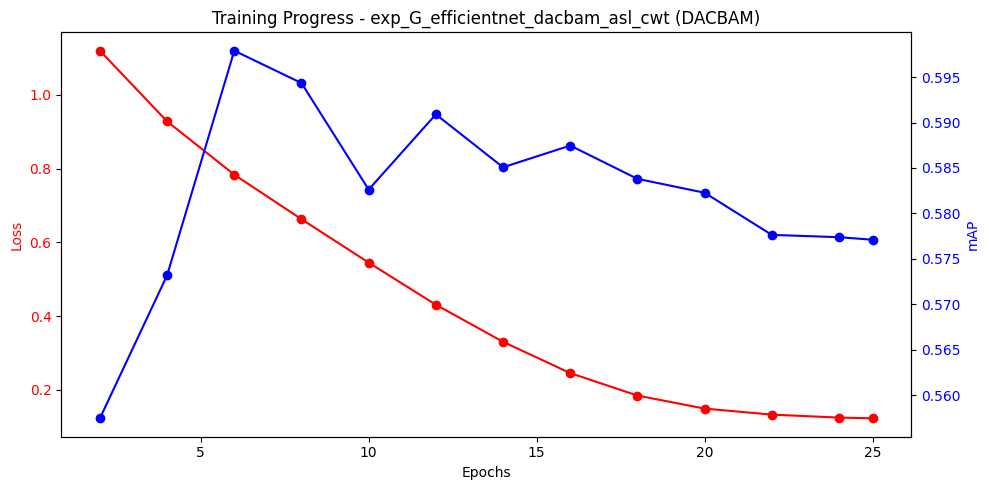

In [4]:
EXP_NAME = 'exp_G_efficientnet_b3_cbam_asl'
LOG_FILE = f'/kaggle/working/outputs/{EXP_NAME}/log.json'

import os, json, matplotlib.pyplot as plt
if os.path.exists(LOG_FILE):
    with open(LOG_FILE) as f:
        logs = json.load(f)
    epochs = [r['epoch'] for r in logs]
    train_loss = [r.get('train_loss', 0) for r in logs]
    val_map = [r.get('mAP', 0) for r in logs]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs, train_loss, 'r-o', label='Train Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color='r')
    ax1.tick_params(axis='y', labelcolor='r')

    ax2 = ax1.twinx()
    ax2.plot(epochs, val_map, 'b-o', label='Val mAP')
    ax2.set_ylabel('mAP', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.title('Training Progress - ' + EXP_NAME)
    fig.tight_layout()
    plt.savefig('/kaggle/working/training_progress.png', dpi=100)
    plt.show()
    best = max(logs, key=lambda r: r.get('mAP', 0))
    print('Best epoch: %d | Val mAP: %.4f | Macro-F1: %.4f' % (best['epoch'], best['mAP'], best.get('macro_f1', 0)))
else:
    print('Log file not found:', LOG_FILE)


In [5]:
from models import build_model
from evaluate import evaluate_model
from dataset import COCOMultiLabelDataset, get_val_transform, get_train_transform
from torch.utils.data import DataLoader
import yaml

with open(config_path) as f:
    cfg = yaml.safe_load(f)
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_model(cfg['model']).to(device)
best_pth = f'/kaggle/working/outputs/{EXP_NAME}/best.pth'

if os.path.exists(best_pth):
    # Đã sửa lỗi UnpicklingError: weights_only=False và lấy key 'model' thay vì 'model_state_dict'
    model.load_state_dict(torch.load(best_pth, map_location=device, weights_only=False)['model'])
    print(f"Loaded best.pth từ {EXP_NAME}")
else:
    print(f"CẢNH BÁO: Không tìm thấy {best_pth}!")

coco_root = cfg['data']['data_root']
test_ids_file = SUBSET_DIR / 'subset_test_ids.json'
test_ids = json.load(open(test_ids_file)) if test_ids_file.exists() else None
train_ids_file = SUBSET_DIR / 'subset_train_ids.json'
train_ids = json.load(open(train_ids_file)) if train_ids_file.exists() else None

test_ds = COCOMultiLabelDataset(coco_root, split='val', transform=get_val_transform(224), subset_ids=test_ids)
test_loader = DataLoader(test_ds, batch_size=32, num_workers=2, shuffle=False)

train_ds = COCOMultiLabelDataset(coco_root, split='train', transform=get_val_transform(224), subset_ids=train_ids)
train_loader = DataLoader(train_ds, batch_size=32, num_workers=2, shuffle=False)

print("\n--- ĐANG ĐÁNH GIÁ TRÊN TẬP TEST SET ---")
test_metrics = evaluate_model(model, test_loader, device)
print(f"Test mAP:       {test_metrics['mAP']:.4f}")
print(f"Test Macro F1:  {test_metrics['macro_f1']:.4f} (Đã tối ưu bằng Class-wise Threshold)")
print(f"Test Micro F1:  {test_metrics['micro_f1']:.4f}")

print("\n--- ĐANG ĐÁNH GIÁ TRÊN TẬP TRAIN SET ĐỂ ĐO OVERFIT GAP ---")
train_metrics = evaluate_model(model, train_loader, device)
print(f"Train mAP:      {train_metrics['mAP']:.4f}")

gap = train_metrics['mAP'] - test_metrics['mAP']
print(f"\nOVERFITTING GAP (Train mAP - Test mAP): {gap*100:.2f}%")
print("Nhận xét: Nếu GAP này nhỏ hơn mức 20% của mô hình C cũ, nghĩa là DACBAM đã hoàn thành xuất sắc nhiệm vụ chống Overfit!")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
Loaded best.pth từ exp_G_efficientnet_dacbam_asl_cwt
[COCO 2017 val] 3,952 images loaded
[COCO 2017 train] 16,000 images loaded

--- ĐANG ĐÁNH GIÁ TRÊN TẬP TEST SET ---
Test mAP:       0.6076
Test Macro F1:  0.5947 (Đã tối ưu bằng Class-wise Threshold)
Test Micro F1:  0.6454

--- ĐANG ĐÁNH GIÁ TRÊN TẬP TRAIN SET ĐỂ ĐO OVERFIT GAP ---
Train mAP:      0.7937

OVERFITTING GAP (Train mAP - Test mAP): 18.62%
Nhận xét: Nếu GAP này nhỏ hơn mức 20% của mô hình C cũ, nghĩa là DACBAM đã hoàn thành xuất sắc nhiệm vụ chống Overfit!
